## Imports

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_style("whitegrid")

In [2]:
DATA_PATH = Path("../data/MachineLearningRating_v3.txt")

df = pd.read_csv(
    DATA_PATH,
    sep="|",
    low_memory=False
)

df.head()

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,MaritalStatus,Gender,Country,Province,PostalCode,MainCrestaZone,SubCrestaZone,ItemType,mmcode,VehicleType,RegistrationYear,make,Model,Cylinders,cubiccapacity,kilowatts,bodytype,NumberOfDoors,VehicleIntroDate,CustomValueEstimate,AlarmImmobiliser,TrackingDevice,CapitalOutstanding,NewVehicle,WrittenOff,Rebuilt,Converted,CrossBorder,NumberOfVehiclesInFleet,SumInsured,TermFrequency,CalculatedPremiumPerTerm,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,119300.00,Monthly,584.6468,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,119300.00,Monthly,584.6468,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   UnderwrittenCoverID       1000098 non-null  int64  
 1   PolicyID                  1000098 non-null  int64  
 2   TransactionMonth          1000098 non-null  str    
 3   IsVATRegistered           1000098 non-null  bool   
 4   Citizenship               1000098 non-null  str    
 5   LegalType                 1000098 non-null  str    
 6   Title                     1000098 non-null  str    
 7   Language                  1000098 non-null  str    
 8   Bank                      854137 non-null   str    
 9   AccountType               959866 non-null   str    
 10  MaritalStatus             991839 non-null   str    
 11  Gender                    990562 non-null   str    
 12  Country                   1000098 non-null  str    
 13  Province                  1000098 non-

In [4]:
object_cols = df.select_dtypes(include="object").columns

print(object_cols)
print(len(object_cols))

Index(['TransactionMonth', 'Citizenship', 'LegalType', 'Title', 'Language',
       'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province',
       'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'VehicleType', 'make',
       'Model', 'bodytype', 'VehicleIntroDate', 'AlarmImmobiliser',
       'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff',
       'Rebuilt', 'Converted', 'CrossBorder', 'TermFrequency',
       'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section',
       'Product', 'StatutoryClass', 'StatutoryRiskType'],
      dtype='str')
36


C:\Users\Dataencoder\AppData\Local\Temp\ipykernel_14732\113848702.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include="object").columns


In [5]:
for col in object_cols:
    df[col] = df[col].astype(str).str.strip()

In [6]:
df.replace(
    ["", " ", "nan", "None"],
    np.nan,
    inplace=True
)

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,MaritalStatus,Gender,Country,Province,PostalCode,MainCrestaZone,SubCrestaZone,ItemType,mmcode,VehicleType,RegistrationYear,make,Model,Cylinders,cubiccapacity,kilowatts,bodytype,NumberOfDoors,VehicleIntroDate,CustomValueEstimate,AlarmImmobiliser,TrackingDevice,CapitalOutstanding,NewVehicle,WrittenOff,Rebuilt,Converted,CrossBorder,NumberOfVehiclesInFleet,SumInsured,TermFrequency,CalculatedPremiumPerTerm,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,NaN,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,NaN,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,NaN,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,NaN,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,119300.00,Monthly,584.6468,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,NaN,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,119300.00,Monthly,584.6468,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000093,31520,389,2015-04-01 00:00:00,False,ZW,Individual,Mr,English,ABSA Bank,Savings account,Single,Male,South Africa,Western Cape,7493,Karoo 1 (Northeast of Cape Town),Northeast of CT,Mobility - Motor,4614100.0,Passenger Vehicle,2013,B.A.W,SASUKA 2.7i (16 SEAT),4.0,2693.0,110.0,B/S,4.0,2013/01/01 12:00:00 AM,NaN,Yes,No,0,More than 6 months,No,No,No,NaN,NaN,500000.00,Monthly,395.8481,No excess,Third Party,Third Party,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial 

In [7]:
date_cols = [
    "TransactionMonth",
    "VehicleIntroDate"
]

for col in date_cols:
    df[col] = pd.to_datetime(
        df[col],
        errors="coerce"
    )

C:\Users\Dataencoder\AppData\Local\Temp\ipykernel_14732\2254699722.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(


In [10]:
# df[date_cols].info()

In [9]:
binary_cols = [
    "AlarmImmobiliser",
    "TrackingDevice",
    "WrittenOff",
    "Rebuilt",
    "Converted",
    "CrossBorder",
    "NewVehicle",
    "IsVATRegistered"
]

mapping = {
    "Yes": 1,
    "No": 0,
    "True": 1,
    "False": 0
}

for col in binary_cols:
    df[col] = df[col].map(mapping)

In [12]:
# df[binary_cols].head()

In [13]:
for col in df.columns:
    if df[col].dtype == "object":
        print(col)

In [15]:
numeric_cols = [
    "TotalPremium",
    "TotalClaims",
    "CustomValueEstimate",
    "RegistrationYear",
    "kilowatts",
    "cubiccapacity",
    "NumberOfDoors",
    "Cylinders",
    "SumInsured",
    "CalculatedPremiumPerTerm"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

In [17]:
# df[numeric_cols].info()

In [18]:
missing_values = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing_values.head(30)

IsVATRegistered            1000098
NewVehicle                 1000098
NumberOfVehiclesInFleet    1000098
CrossBorder                 999400
Citizenship                 895210
CustomValueEstimate         779642
Converted                   641901
Rebuilt                     641901
WrittenOff                  641901
Bank                        145961
AccountType                  40232
Gender                        9536
MaritalStatus                 8259
make                           552
VehicleType                    552
mmcode                         552
bodytype                       552
kilowatts                      552
NumberOfDoors                  552
VehicleIntroDate               552
Cylinders                      552
Model                          552
cubiccapacity                  552
CapitalOutstanding               2
SubCrestaZone                    0
ItemType                         0
PostalCode                       0
MainCrestaZone                   0
Language            

In [19]:
missing_percent = (
    df.isnull()
      .mean() * 100
).sort_values(ascending=False)

missing_percent.head(30)

IsVATRegistered            100.000000
NewVehicle                 100.000000
NumberOfVehiclesInFleet    100.000000
CrossBorder                 99.930207
Citizenship                 89.512228
CustomValueEstimate         77.956560
Converted                   64.183810
Rebuilt                     64.183810
WrittenOff                  64.183810
Bank                        14.594670
AccountType                  4.022806
Gender                       0.953507
MaritalStatus                0.825819
make                         0.055195
VehicleType                  0.055195
mmcode                       0.055195
bodytype                     0.055195
kilowatts                    0.055195
NumberOfDoors                0.055195
VehicleIntroDate             0.055195
Cylinders                    0.055195
Model                        0.055195
cubiccapacity                0.055195
CapitalOutstanding           0.000200
SubCrestaZone                0.000000
ItemType                     0.000000
PostalCode  

In [20]:
missing_percent = (
    df.isnull()
      .mean() * 100
).sort_values(ascending=False)

missing_percent.head(30)

IsVATRegistered            100.000000
NewVehicle                 100.000000
NumberOfVehiclesInFleet    100.000000
CrossBorder                 99.930207
Citizenship                 89.512228
CustomValueEstimate         77.956560
Converted                   64.183810
Rebuilt                     64.183810
WrittenOff                  64.183810
Bank                        14.594670
AccountType                  4.022806
Gender                       0.953507
MaritalStatus                0.825819
make                         0.055195
VehicleType                  0.055195
mmcode                       0.055195
bodytype                     0.055195
kilowatts                    0.055195
NumberOfDoors                0.055195
VehicleIntroDate             0.055195
Cylinders                    0.055195
Model                        0.055195
cubiccapacity                0.055195
CapitalOutstanding           0.000200
SubCrestaZone                0.000000
ItemType                     0.000000
PostalCode  

In [26]:
df["LossRatio"] = (
    df["TotalClaims"] /
    df["TotalPremium"]
)

In [27]:
df["LossRatio"] = df["LossRatio"].replace(
    [np.inf, -np.inf],
    np.nan
)

In [28]:
df["Margin"] = (
    df["TotalPremium"] -
    df["TotalClaims"]
)

In [29]:
df["VehicleAge"] = (
    2015 - df["RegistrationYear"]
)

In [30]:
df["HasClaim"] = (
    df["TotalClaims"] > 0
).astype(int)

In [31]:
CLEAN_PATH = "../data/cleaned_insurance_data.csv"

df.to_csv(
    CLEAN_PATH,
    index=False
)

## PLOTS

### DISTRIBUTION OF TOTAL CLAIMS

The data is extremely right skewed and hence, the plot is statistically useless. To fix this, I filtered out extreme outliers for visualization without altering the dataset.

In [33]:
claims_filtered = df[
    df["TotalClaims"] < 20000
]

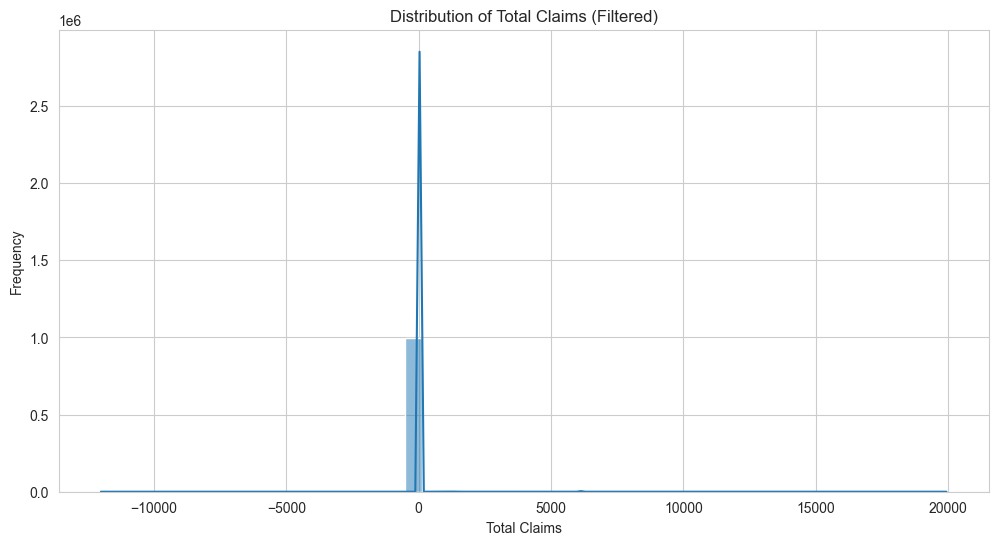

In [34]:
plt.figure(figsize=(12, 6))

sns.histplot(
    claims_filtered["TotalClaims"],
    bins=50,
    kde=True
)

plt.title("Distribution of Total Claims (Filtered)")
plt.xlabel("Total Claims")
plt.ylabel("Frequency")

plt.show()

### OUTLIER BOXPLOT

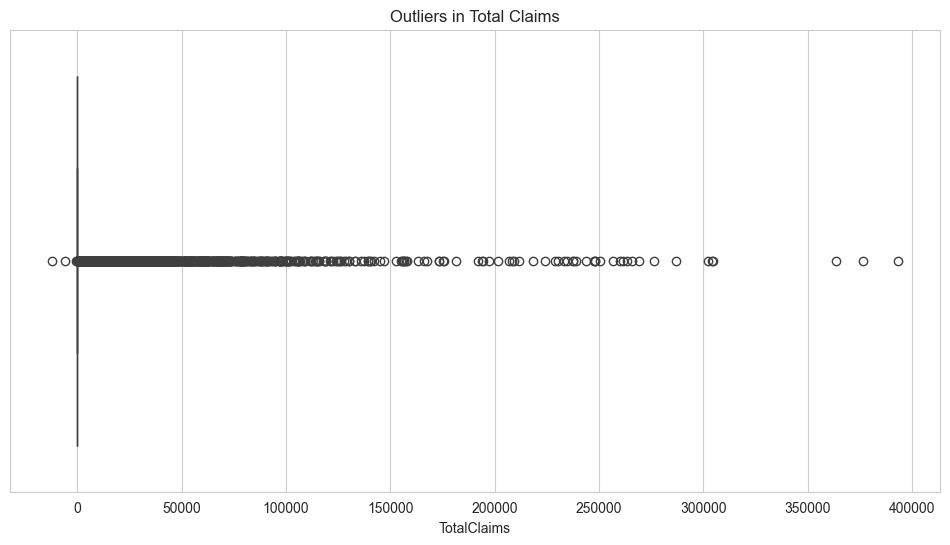

In [35]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    x=df["TotalClaims"]
)

plt.title("Outliers in Total Claims")
plt.show()

### PROVINCE LOSS RATIO ANALYSIS

In [36]:
province_loss = (
    df.groupby("Province")["LossRatio"]
      .mean()
      .sort_values(ascending=False)
)

province_loss

Province
Gauteng          0.428889
Mpumalanga       0.392698
Limpopo          0.348712
Western Cape     0.341750
North West       0.285348
KwaZulu-Natal    0.264746
Eastern Cape     0.235589
Northern Cape    0.203831
Free State       0.106209
Name: LossRatio, dtype: float64

### PROVINCE RISK

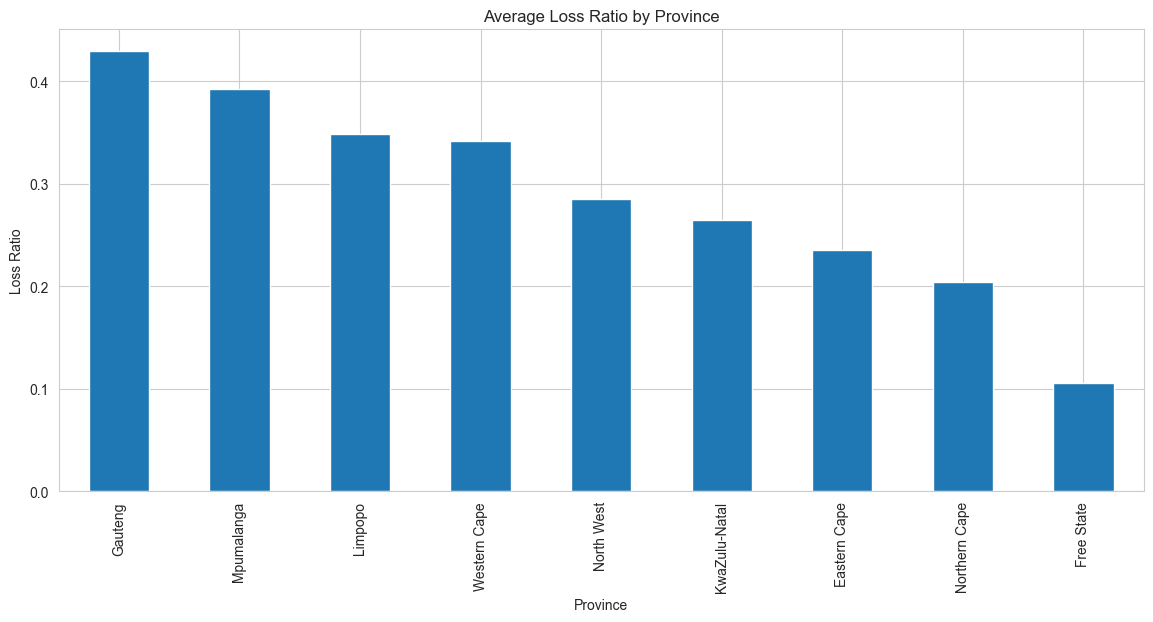

In [37]:
plt.figure(figsize=(14, 6))

province_loss.plot(
    kind="bar"
)

plt.title("Average Loss Ratio by Province")
plt.ylabel("Loss Ratio")

plt.show()

### TEMPORAL TREND ANALYSIS

In [38]:
monthly_claims = (
    df.groupby(
        df["TransactionMonth"].dt.to_period("M")
    )["TotalClaims"]
    .sum()
)

monthly_claims

TransactionMonth
2013-10    0.000000e+00
2013-11    5.058508e+04
2013-12    9.283386e+03
2014-01    1.243686e+04
2014-02    6.298931e+04
2014-03    3.227850e+05
2014-04    3.068636e+05
2014-05    5.180427e+05
2014-06    5.045364e+05
2014-07    4.289822e+05
2014-08    6.934197e+05
2014-09    9.089024e+05
2014-10    1.764693e+06
2014-11    3.794245e+06
2014-12    6.237473e+06
2015-01    5.494524e+06
2015-02    6.267653e+06
2015-03    7.474981e+06
2015-04    9.076825e+06
2015-05    6.963110e+06
2015-06    6.204182e+06
2015-07    6.751214e+06
2015-08    1.019819e+06
Freq: M, Name: TotalClaims, dtype: float64

### TEMPORAL CLAIM TREND

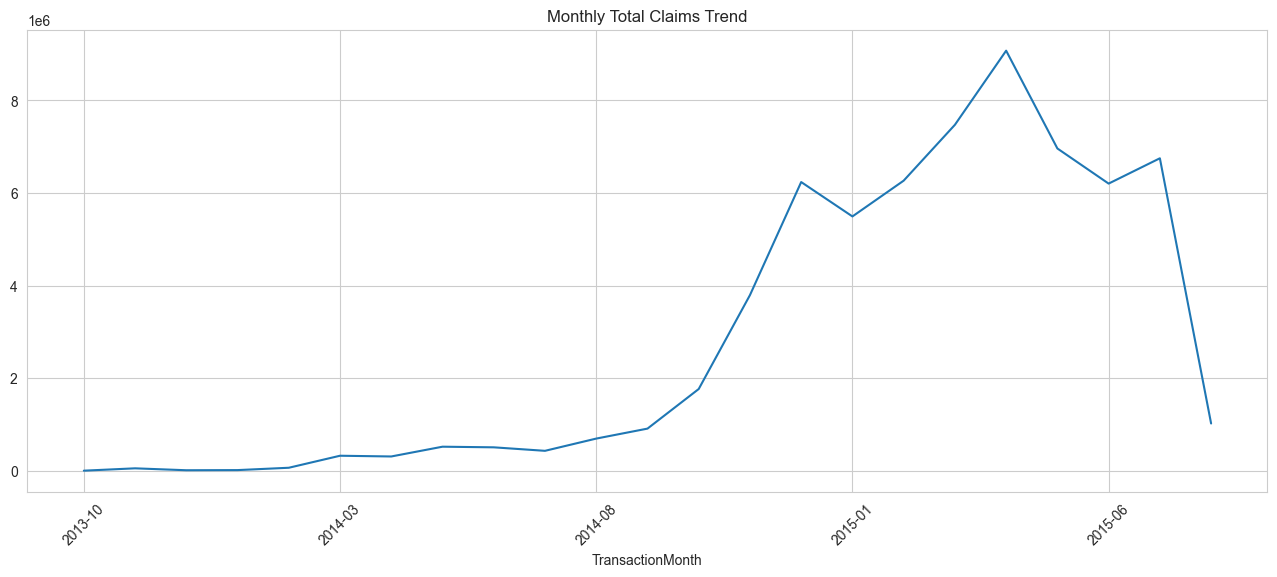

In [39]:
monthly_claims.index = monthly_claims.index.astype(str)

plt.figure(figsize=(16, 6))

monthly_claims.plot()

plt.title("Monthly Total Claims Trend")

plt.xticks(rotation=45)

plt.show()

### VEHICLE MODEL RISK ANALYSIS

In [40]:
model_risk = (
    df.groupby("Model")["TotalClaims"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

model_risk

Model
L/CRUISER FJ 4.0 V6 CRUISER    5340.970273
H-1 2.5 CRDI WAGON A/T         4118.181043
DUCATO 2.3 JTD VETRATO         1014.681021
POLO VIVO 1.6 5Dr               827.558882
C180 BE COUPE                   743.459027
SPRINTER 312D F/C P/V           664.540138
ERTIGA 1.4 GA                   631.774519
YARIS T1 3Dr                    618.719846
A4 1.8T S AVANT MULTITRONIC     480.282859
POLO 1.6 COMFORTLINE            431.842105
ALMERA 1.5 ACENTA               413.063567
320d (E90)                      399.995387
COROLLA 1.4 PROFESSIONAL        392.660860
VERSO 180 SX                    361.289143
SPRINTER 519 CDi XL F/C P/V     357.142028
Name: TotalClaims, dtype: float64

### TOP RISKY VEHICLES

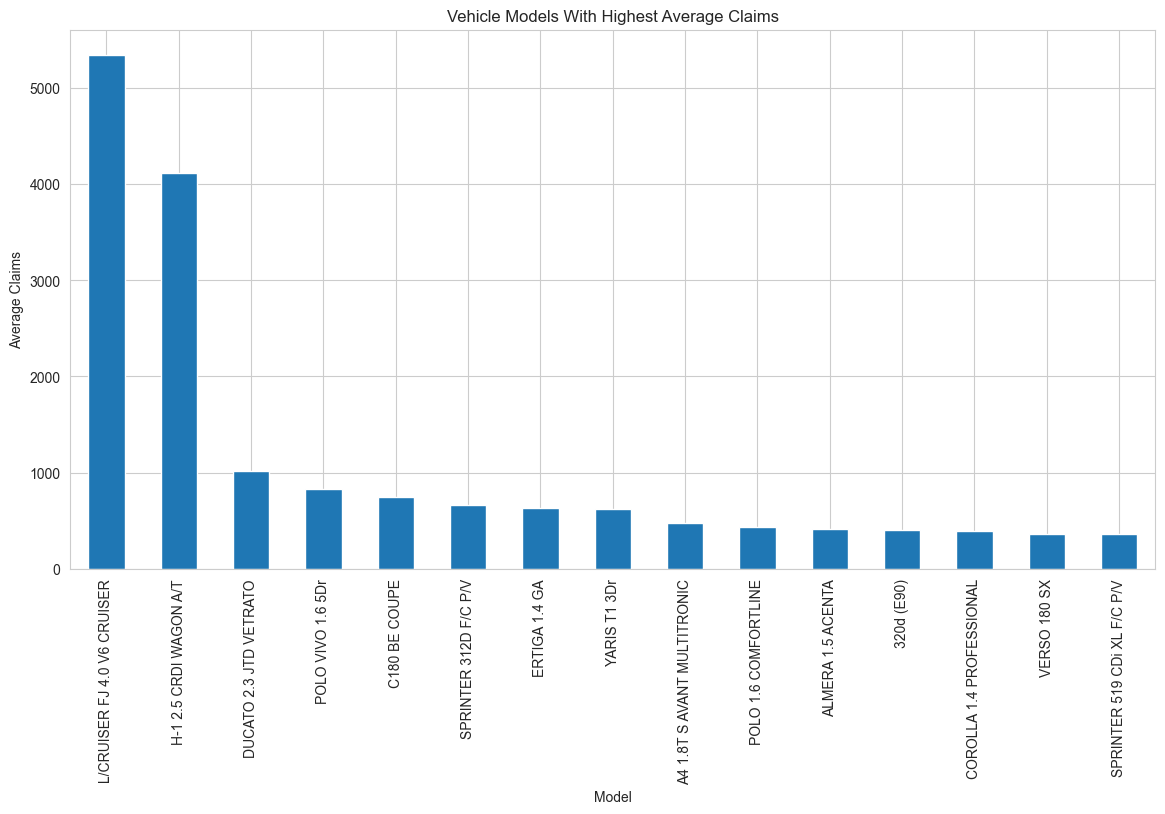

In [41]:
plt.figure(figsize=(14, 7))

model_risk.plot(kind="bar")

plt.title("Vehicle Models With Highest Average Claims")

plt.ylabel("Average Claims")

plt.show()

In [ ]:
from src.eda_utils import (
    plot_distribution,
    missing_values_summary
)

### Missing Value Analysis

Several columns contain missing values, particularly categorical and policy-related fields. Missingness appears to be non-random in certain variables and may reflect incomplete customer declarations or unavailable underwriting information.

In [48]:
missing_summary = missing_values_summary(df)

missing_summary.head(20)

,missing_count,missing_percent
IsVATRegistered,1000098,100.000000
NumberOfVehiclesInFleet,1000098,100.000000
NewVehicle,1000098,100.000000
CrossBorder,999400,99.930207
Citizenship,895210,89.512228
CustomValueEstimate,779642,77.956560
Converted,641901,64.183810
WrittenOff,641901,64.183810
Rebuilt,641901,64.183810
LossRatio,381634,38.159660


### Premium Distribution Analysis

The TotalPremium distribution is positively skewed, indicating that most policyholders pay relatively low premiums while a smaller subset pays substantially higher amounts. This pattern is common in insurance pricing structures where risk segmentation drives premium differentiation.

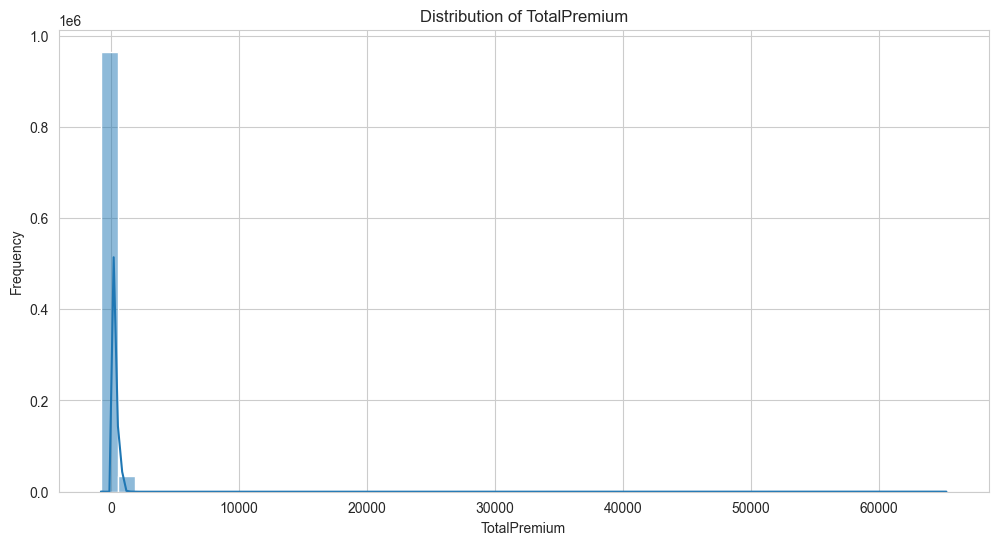

In [49]:
plot_distribution(
    df,
    "TotalPremium"
)

### Provincial Risk Analysis

Claim severity varies substantially across provinces, suggesting geographic risk segmentation opportunities. Certain provinces exhibit consistently higher average claim amounts, which may justify differentiated underwriting strategies and premium pricing adjustments.

In [50]:
province_claims = (
    df.groupby("Province")["TotalClaims"]
      .mean()
      .sort_values(ascending=False)
)

province_claims

Province
KwaZulu-Natal    84.234293
Gauteng          74.630009
Western Cape     60.831482
Eastern Cape     44.713432
Free State       43.822975
North West       41.317426
Limpopo          40.927553
Mpumalanga       38.785147
Northern Cape    14.026726
Name: TotalClaims, dtype: float64

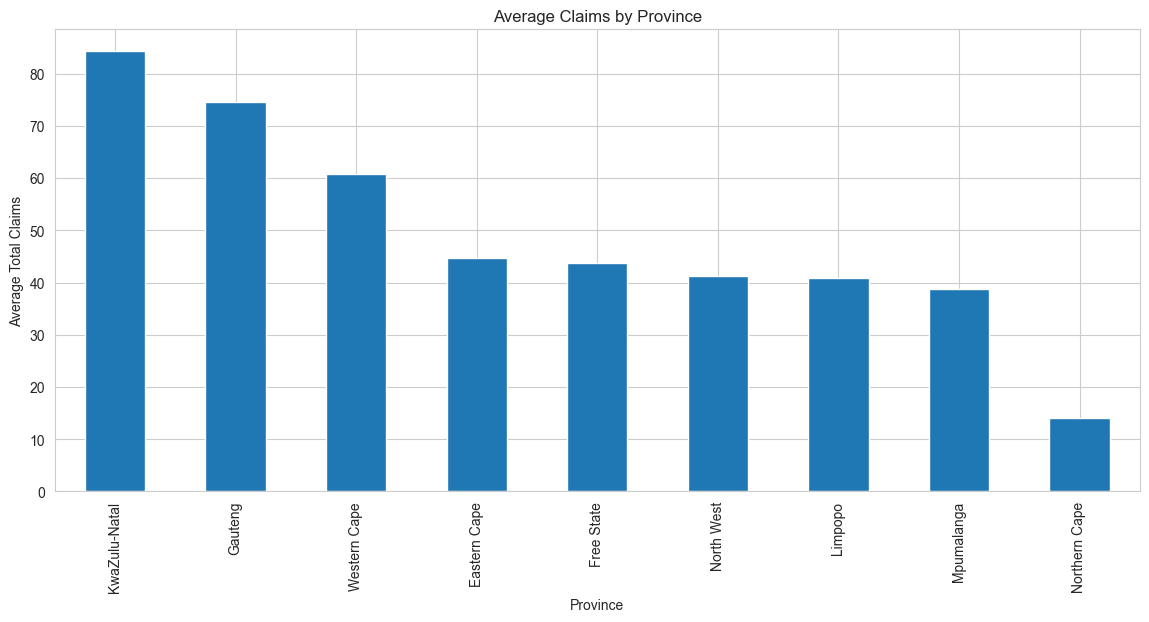

In [51]:
plt.figure(figsize=(14, 6))

province_claims.plot(
    kind="bar"
)

plt.title("Average Claims by Province")

plt.ylabel("Average Total Claims")

plt.show()

### Vehicle Risk Analysis

Vehicle categories demonstrate heterogeneous claim behavior. High-risk vehicle types may require stricter underwriting controls and differentiated pricing structures.

In [52]:
vehicle_claims = (
    df.groupby("VehicleType")["TotalClaims"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

vehicle_claims

VehicleType
Heavy Commercial     101.401781
Medium Commercial     76.315030
Passenger Vehicle     63.594898
Light Commercial      15.512574
Bus                   12.024865
Name: TotalClaims, dtype: float64

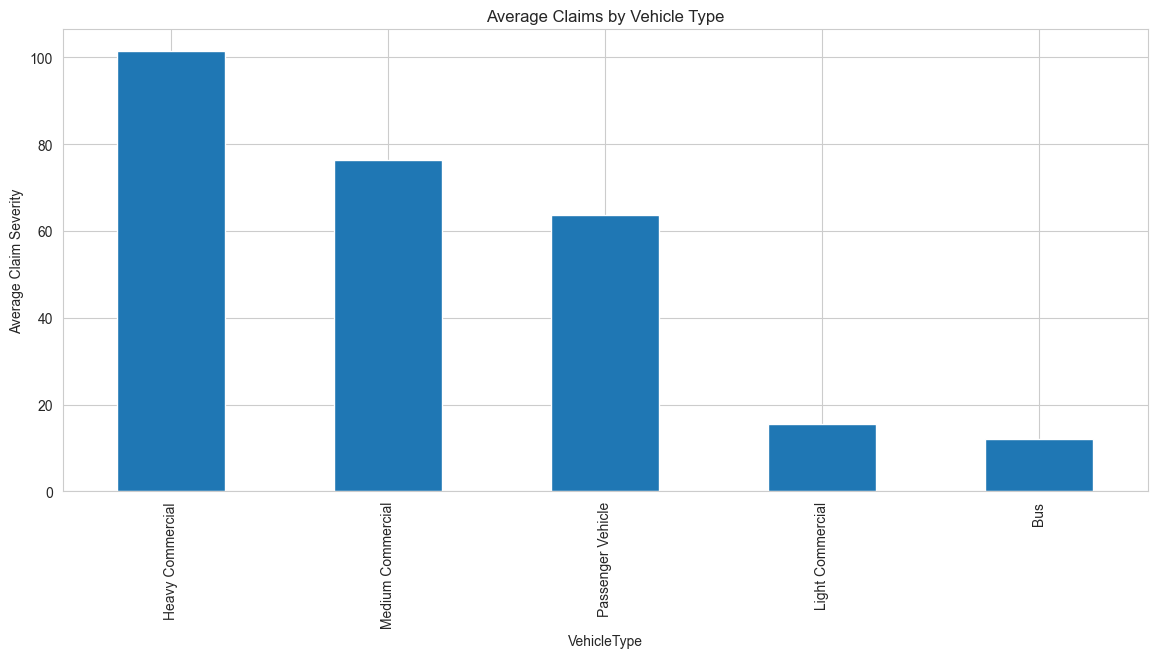

In [53]:
plt.figure(figsize=(14, 6))

vehicle_claims.plot(
    kind="bar"
)

plt.title("Average Claims by Vehicle Type")

plt.ylabel("Average Claim Severity")

plt.show()

### Premium and Claims Relationship

Policies with higher premiums generally correspond to higher claim exposure, indicating that underwriting pricing mechanisms partially capture underlying risk characteristics.

In [55]:
sample_df = df.sample(
    min(5000, len(df)),
    random_state=42
)

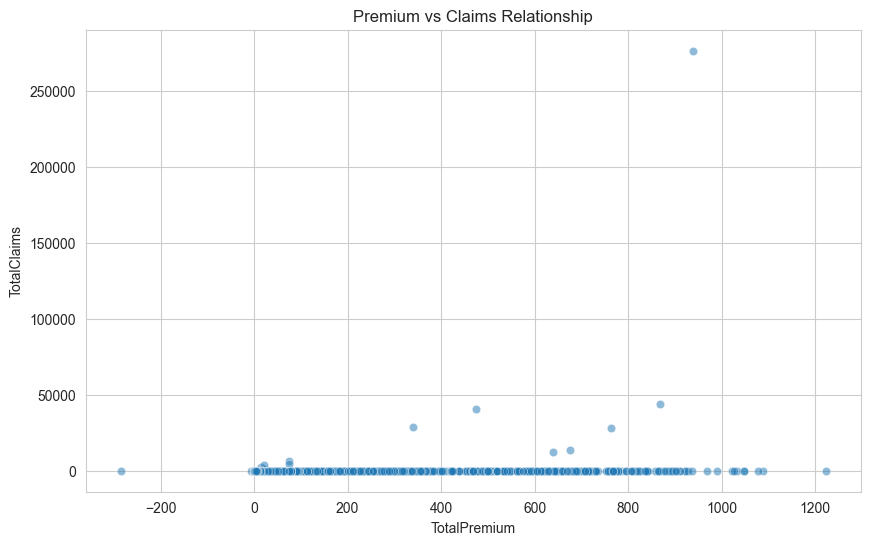

In [56]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sample_df,
    x="TotalPremium",
    y="TotalClaims",
    alpha=0.5
)

plt.title("Premium vs Claims Relationship")

plt.show()

### Temporal Trend Analysis

Monthly claim trends reveal fluctuations in insurance risk over time. Temporal volatility may reflect seasonality, operational factors, or changing customer behavior.

In [57]:
monthly_claims = (
    df.groupby(
        df["TransactionMonth"].dt.to_period("M")
    )["TotalClaims"]
    .mean()
)

monthly_claims

TransactionMonth
2013-10     0.000000
2013-11    42.295217
2013-12     6.209623
2014-01     6.807258
2014-02    30.547676
2014-03    93.128973
2014-04    44.350859
2014-05    54.622811
2014-06    42.677753
2014-07    28.777234
2014-08    35.331688
2014-09    34.971237
2014-10    52.178981
2014-11    78.640464
2014-12    99.868279
2015-01    76.764888
2015-02    75.334178
2015-03    81.236553
2015-04    93.998999
2015-05    69.702195
2015-06    60.473143
2015-07    64.826388
2015-08     9.553607
Freq: M, Name: TotalClaims, dtype: float64

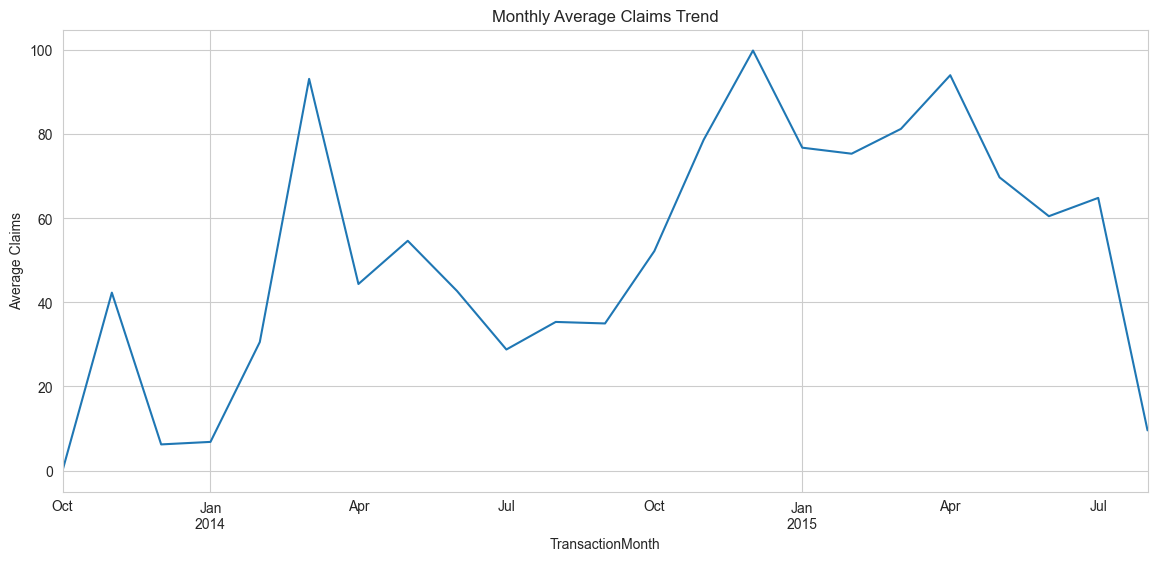

: 

In [ ]:
plt.figure(figsize=(14, 6))

monthly_claims.plot()

plt.title("Monthly Average Claims Trend")

plt.ylabel("Average Claims")

plt.show()